# The Unitarity Triangle Treasure Hunt
### A hands-on lesson for "Flavour at LHC" students

---

## 🕵️ Your Mission

Somewhere in the complex plane, hidden at mysterious coordinates $(\bar\rho,\,\bar\eta)$, lies the **apex of the Unitarity Triangle** — the key to understanding *CP violation* in the Standard Model.

Your job: act as a particle-physics **detective**. Nature has scattered clues through experiments at Belle, LHCb, BaBar, NA48, and more. Each measurement draws a **band on the map**; when all bands overlap, **X marks the spot**.

---

## 🗺️ How the Hunt Works

| Step | What you do |
|------|-------------|
| 📖 Read the lore | Each chapter gives you theory background |
| 🔐 Crack the code | Fill in the missing Python functions |
| 🧪 Run the check | Auto-grader tells you if you're right |
| 📍 Watch the map | Your band appears on the treasure map |
| 🏆 Find the apex | When all clues converge — you win! |

---

## 🏅 Scoring

- ✅ Correct exercise: **+10 points**
- ⭐ Bonus challenge: **+5 points**
- 🏆 Full triangle revealed: **+20 points**
- Max score: **95 points**

---

> *" A nice citation would fit nicely here "* by Anonymous

Run **Cell 2** to set up your equipment and start the hunt!

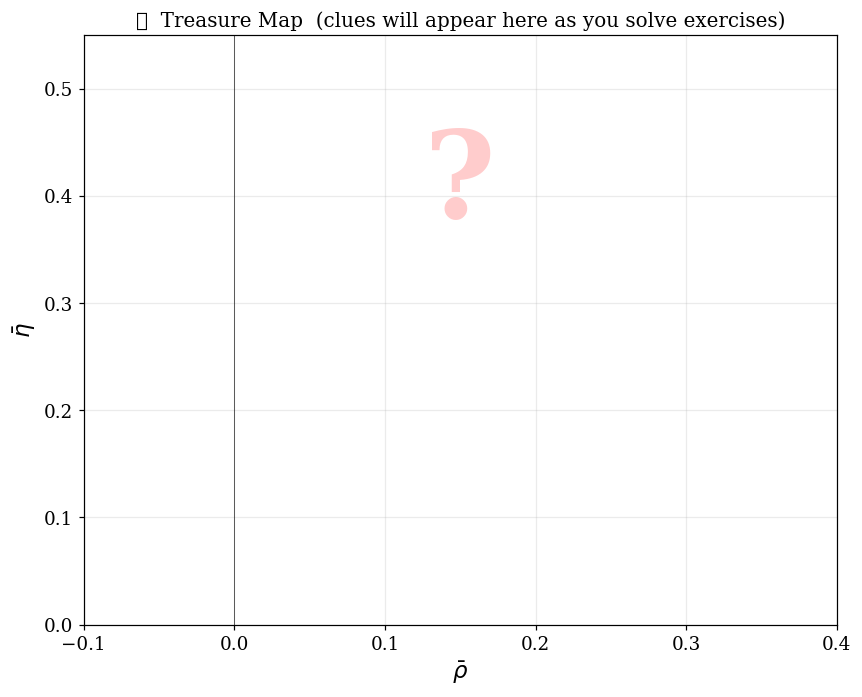

✅  Equipment ready — good luck, detective!
   numpy 2.2.6  |  scipy available


In [6]:
# ===========================================================
#  MISSION EQUIPMENT — run this first!
# ===========================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Arc
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'figure.dpi': 110, 'text.usetex': False,
})

# ── Score tracker ────────────────────────────────────────────
class TreasureHunt:
    def __init__(self):
        self.score = 0
        self.clues = []
        self._bands = {}   # name -> (F, val, err, colour)

    def award(self, points, name):
        self.score += points
        self.clues.append(name)
        print(f"  ✅  Clue decoded: '{name}'  +{points} pts")
        print(f"  🏅  Running total: {self.score} pts\n")

    def status(self):
        bar = "█" * self.score + "░" * max(0, 95 - self.score)
        print(f"\n{'='*52}")
        print(f"  🗺️   OPERATION CKM — STATUS REPORT")
        print(f"{'='*52}")
        print(f"  Score  [{bar[:30]}]  {self.score}/95")
        print(f"  Clues found : {len(self.clues)}/6")
        for c in self.clues:
            print(f"    ✓ {c}")
        remaining = 6 - len(self.clues)
        if remaining:
            print(f"  ⏳  {remaining} clue(s) still hidden…")
        else:
            print("  🏆  ALL CLUES FOUND — time to dig!")
        print(f"{'='*52}\n")

hunt = TreasureHunt()

# ── Live treasure map ────────────────────────────────────────
RHO_LIM = (-0.10, 0.40)
ETA_LIM = (0.0,  0.55)

_rho_v = np.linspace(*RHO_LIM, 300)
_eta_v = np.linspace(*ETA_LIM, 300)
RHO_G, ETA_G = np.meshgrid(_rho_v, _eta_v)

def show_map(title="🗺️  Treasure Map", new=True):
    """Re-draw the accumulating treasure map."""
    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.set_xlim(*RHO_LIM); ax.set_ylim(*ETA_LIM)
    ax.set_xlabel(r'$\bar{\rho}$', fontsize=15)
    ax.set_ylabel(r'$\bar{\eta}$', fontsize=15)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.25)
    ax.axhline(0, color='k', lw=0.4)
    ax.axvline(0, color='k', lw=0.4)
    # watermark
    ax.text(0.15, 0.38, "?", fontsize=80, alpha=0.20, ha='center',
            color='red', fontweight='bold')
    legend_handles = []
    for name, (fn, val, err, col) in hunt._bands.items():
        F = np.vectorize(fn)(RHO_G, ETA_G)
        mask = np.abs(F - val) < err
        ax.contourf(RHO_G, ETA_G, mask.astype(float),
                    levels=[0.5, 1.5], colors=[col], alpha=0.30)
        ax.contour(RHO_G, ETA_G, F, levels=[val],
                   colors=[col], linewidths=1.6, linestyles='--')
        legend_handles.append(
            mpatches.Patch(facecolor=col, alpha=0.5, label=name))
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', fontsize=10)
    plt.tight_layout(); plt.show()

show_map("Treasure Map  (clues will appear here as you solve exercises)")
print("✅  Equipment ready — good luck, detective!")
print(f"   numpy {np.__version__}  |  scipy available")